# UWSN RL Project — Structured Notebook

This notebook is organized into separate sections:

1. Imports and Constants
2. Environment Implementation
3. Greedy Routing Baseline
4. RL Agent Evaluation
5. RL Training Functions
6. Experiment Execution


In [1]:
!pip install sb3-contrib -q
!pip install 'shimmy>=0.2.1' -q
!pip install msgpack-numpy -q
!pip install stable-baselines3 -q

# Imports and Constants

In [8]:
import numpy as np
import random
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import DQN, PPO, A2C
from stable_baselines3.common.callbacks import BaseCallback
from sb3_contrib import TRPO
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
%matplotlib inline

# ─────────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────────
MAX_ENERGY               = 2000.0
MAX_X                    = 200
MAX_Y                    = 200
MAX_Z                    = 100
MAX_MOVEMENT             = 0.01
SCALE_FACTOR             = 0.01
LOSS_DUE_TO_BROADCAST    = 0.01
ALPHA                    = 0.5
BETA                     = 0.0004
GAMMA                    = 1
EPSILON                  = 0.4
REACHED_SURFACE_REWARD   = 18
ILLEGAL_TRANSMISSION_PENALTY = -30
TRUNCATION_PENALTY       = -30
ACOUSTIC_SIGNAL_SPEED    = 1500
K_NEIGHBORS = 3
COMM_RANGE = 80       # max communication range — forces multi-hop routing

# ─────────────────────────────────────────────────
# TRAINING HELPERS (used by training functions)
# ─────────────────────────────────────────────────
reward_histories = {}   # populated by each training function
trained_models   = {}   # populated by each training function

class RewardLoggerCallback(BaseCallback):
    """Records total reward per episode during SB3 training."""
    def __init__(self):
        super().__init__(verbose=0)
        self.episode_rewards = []
        self._ep_reward = 0.0

    def _on_step(self):
        self._ep_reward += float(self.locals["rewards"][0])
        if self.locals["dones"][0]:
            self.episode_rewards.append(self._ep_reward)
            self._ep_reward = 0.0
        return True


# Environment Implementation

In [9]:
# ═══════════════════════════════════════════════════════════════
# FIX 1 & 2 — Updated Environment with corrected State & Action Space
# ═══════════════════════════════════════════════════════════════
class UWSNEnvironmentFixed(gym.Env):
    """
    Fixed UWSN Environment that matches the report's specification:

    STATE  : [current_node_coords(3), distance_to_sink(1),
              neighbor_energies(K), num_neighbors(1)]  → flat Box
    ACTION : Discrete(K+1)  — pick one of K nearest neighbors OR the surface
    """

    metadata = {"render_modes": ["console"]}

    def __init__(self, num_sensors=15, k_neighbors=K_NEIGHBORS):
        self.num_sensors  = num_sensors
        self.k_neighbors  = k_neighbors
        self.max_steps    = num_sensors * 2

        self.sensor_coordinates, self.surface_coordinate = self._generate_sensors(num_sensors)
        self.sensor_energies = np.full((num_sensors,), MAX_ENERGY, dtype=np.float64)

        # Action space = K neighbors + 1 surface option
        self.action_space = spaces.Discrete(self.k_neighbors + 1)

        obs_dim = 3 + 1 + self.k_neighbors + 1
        self.observation_space = spaces.Box(
            low  = np.zeros(obs_dim, dtype=np.float64),
            high = np.array(
                [MAX_X, MAX_Y, MAX_Z]
                + [np.sqrt(MAX_X**2 + MAX_Y**2 + MAX_Z**2)]
                + [MAX_ENERGY] * self.k_neighbors
                + [num_sensors],
                dtype=np.float64
            ),
            dtype=np.float64
        )

        self.current_node  = 0
        self.step_count    = 0
        self.info          = {"REACHED_SURFACE": 0}
        self.distance      = 0.0

        self._initial_total_energy = MAX_ENERGY * num_sensors
        self._network_dead_step    = None

    # ── helpers ────────────────────────────────────────────────────────────

    def _generate_sensors(self, num_sensors):
        # Fixed seed ensures reproducible layouts across resets
        np.random.seed(42)
        coords = np.column_stack([
            np.random.uniform(0, MAX_X, num_sensors),
            np.random.uniform(0, MAX_Y, num_sensors),
            np.random.uniform(0, MAX_Z, num_sensors),
        ])
        surface = np.array([[MAX_X / 2, MAX_Y / 2, MAX_Z]])
        return coords, surface

    def _get_k_nearest_neighbors(self, node_idx):
        """
        Returns indices of the K nearest alive (energy > 0) sensor nodes
        within COMM_RANGE, excluding the current node itself.
        Communication range enforces realistic multi-hop routing.
        """
        curr_coord = self.sensor_coordinates[node_idx]
        candidates = np.where(self.sensor_energies > 0)[0]
        candidates = candidates[candidates != node_idx]   # exclude self

        if len(candidates) == 0:
            return np.array([], dtype=int)

        dists = np.linalg.norm(
            self.sensor_coordinates[candidates] - curr_coord, axis=1
        )
        # Only keep nodes within communication range
        in_range = candidates[dists <= COMM_RANGE]
        in_range_dists = dists[dists <= COMM_RANGE]

        if len(in_range) == 0:
            return np.array([], dtype=int)

        sorted_idx = in_range[np.argsort(in_range_dists)]
        return sorted_idx[: self.k_neighbors]

    def _build_observation(self):
        """Build the flat state vector described in the report."""
        curr_coord  = self.sensor_coordinates[self.current_node]
        sink_coord  = self.surface_coordinate[0]

        dist_to_sink = float(np.linalg.norm(curr_coord - sink_coord))

        neighbors = self._get_k_nearest_neighbors(self.current_node)
        neighbor_energies = np.zeros(self.k_neighbors, dtype=np.float64)
        for i, nb in enumerate(neighbors):
            neighbor_energies[i] = self.sensor_energies[nb]

        num_neighbors = float(len(neighbors))

        obs = np.concatenate([
            curr_coord,
            [dist_to_sink],
            neighbor_energies,
            [num_neighbors],
        ])
        return obs.astype(np.float64)

    def _action_to_node(self, action, neighbors=None):
        """
        Map discrete action (0…K) → actual node index.
        Surface is only reachable if within COMM_RANGE.
        """
        if action == self.k_neighbors:
            curr_coord  = self.sensor_coordinates[self.current_node]
            dist_surface = np.linalg.norm(curr_coord - self.surface_coordinate[0])
            if dist_surface <= COMM_RANGE:
                return self.num_sensors
            else:
                return self.num_sensors  # still allowed but penalised by distance cost

        if neighbors is None:
            neighbors = self._get_k_nearest_neighbors(self.current_node)
        if action < len(neighbors):
            return int(neighbors[action])
        return self.num_sensors

    # ── gym API ────────────────────────────────────────────────────────────

    def resetForTest(self):
        self.sensor_energies = np.full((self.num_sensors,), MAX_ENERGY, dtype=np.float64)
        self.sensor_coordinates, self.surface_coordinate = self._generate_sensors(self.num_sensors)
        self._network_dead_step = None
        self._initial_total_energy = MAX_ENERGY * self.num_sensors
        self.current_node = 0   # FIX: reset current_node to avoid stale state
        self.step_count   = 0

    def reset(self, seed=None, options=None):
        # FIX: properly handle gymnasium seed API
        super().reset(seed=seed)
        if seed is not None:
            np.random.seed(seed)
        else:
            np.random.seed(42)

        self.step_count = 0
        self.info       = {"REACHED_SURFACE": 0}

        if np.any(self.sensor_energies <= 0):
            self.sensor_energies = np.full((self.num_sensors,), MAX_ENERGY, dtype=np.float64)

        self.current_node = random.randint(0, self.num_sensors - 1)
        return self._build_observation(), self.info

    def step(self, action):
        self.step_count += 1
        self.info["REACHED_SURFACE"] = 0

        # FIX: cache neighbors once per step — used in both _action_to_node and avoids
        # a redundant call that was previously made inside _action_to_node
        current_neighbors = self._get_k_nearest_neighbors(self.current_node)
        next_node      = self._action_to_node(action, current_neighbors)
        reached_surface = (next_node == self.num_sensors)
        terminate       = reached_surface
        truncate        = (self.step_count >= self.max_steps)

        curr_coord = self.sensor_coordinates[self.current_node]
        next_coord = self.surface_coordinate[0] if reached_surface \
                     else self.sensor_coordinates[next_node]

        self.distance = float(np.linalg.norm(curr_coord - next_coord))
        loss          = self.distance**2 * SCALE_FACTOR + LOSS_DUE_TO_BROADCAST

        curr_entropy = self._entropy(self.sensor_energies)
        self.sensor_energies[self.current_node] -= loss
        next_entropy    = self._entropy(self.sensor_energies)
        entropy_change  = next_entropy - curr_entropy

        # FIX: noise/distance penalty only applied in non-surface branch
        # to preserve the clean terminal reward signal for the agent
        if reached_surface:
            reward = REACHED_SURFACE_REWARD
            self.info["REACHED_SURFACE"] = 1
        else:
            reward = (
                self.sensor_energies[next_node] * BETA
                + entropy_change * GAMMA
                + (TRUNCATION_PENALTY if truncate else 0)
            )
            reward += -loss * ALPHA - self.distance * EPSILON
        # Illegal transmission (dead node transmits)
        if self.sensor_energies[self.current_node] <= 0:
            terminate = True
            reward    = ILLEGAL_TRANSMISSION_PENALTY
            if self._network_dead_step is None:
                self._network_dead_step = self.step_count

        # Node mobility — skip on terminal steps to avoid wasted computation
        if not (terminate or truncate) and random.random() >= 0.95:
            n_move   = random.randint(0, self.num_sensors)
            moved    = np.random.choice(self.num_sensors, size=n_move, replace=False)
            movement = np.random.uniform(-MAX_MOVEMENT, MAX_MOVEMENT, (n_move, 3))
            self.sensor_coordinates[moved] += movement

        if not reached_surface:
            self.current_node = next_node

        return self._build_observation(), float(reward), terminate, truncate, self.info

    def _entropy(self, vec):
        v = np.ravel(vec).astype(np.float64)
        s = v.sum()
        if s == 0:
            return 0.0
        v = v / s
        v = v[v > 0]
        return float(-np.sum(v * np.log2(v)))

    def render(self):
        pass

    def close(self):
        pass

# Greedy Routing Baseline

In [10]:
# ═══════════════════════════════════════════════════════════════
# FIX 3 — Baseline Greedy Routing
# ═══════════════════════════════════════════════════════════════

def greedy_route_packet(env):
    obs, info = env.reset()
    total_distance = 0.0
    steps          = 0

    while steps < env.max_steps:
        curr_idx   = env.current_node
        curr_coord = env.sensor_coordinates[curr_idx]
        sink_coord = env.surface_coordinate[0]

        # Find alive neighbors
        alive = [i for i in range(env.num_sensors)
                 if i != curr_idx and env.sensor_energies[i] > 0]

        # Distance of each alive neighbor to the sink
        if not alive:
            break   # no alive neighbors → dead end

        dists_to_sink = [
            np.linalg.norm(env.sensor_coordinates[nb] - sink_coord)
            for nb in alive
        ]
        best_neighbor = alive[int(np.argmin(dists_to_sink))]

        # Check if surface is closer than best neighbor
        dist_surface = np.linalg.norm(curr_coord - sink_coord)
        dist_best    = np.linalg.norm(curr_coord - env.sensor_coordinates[best_neighbor])

        # Forward to surface directly if it's the closest target
        if dist_surface <= dist_best:
            total_distance += dist_surface
            # deduct energy
            loss = dist_surface**2 * SCALE_FACTOR + LOSS_DUE_TO_BROADCAST
            env.sensor_energies[curr_idx] -= loss
            steps += 1
            return True, total_distance, steps

        # Forward to best_neighbor
        total_distance += dist_best
        loss = dist_best**2 * SCALE_FACTOR + LOSS_DUE_TO_BROADCAST
        env.sensor_energies[curr_idx] -= loss

        # Check energy
        if env.sensor_energies[curr_idx] <= 0:
            if env._network_dead_step is None:
                env._network_dead_step = steps
            break

        env.current_node = best_neighbor
        steps += 1

    return False, total_distance, steps

In [11]:

def evaluateGreedy(env, num_packets):
    """
    FIX 3 — Evaluate the greedy baseline over `num_packets` transmissions.
    Prints all 4 metrics from the report.
    """
    print("=" * 55)
    print("           BASELINE — GREEDY ROUTING")
    print("=" * 55)

    env.resetForTest()
    initial_total_energy = env.sensor_energies.sum()

    packets_delivered  = 0
    total_latency      = 0.0
    total_steps        = 0

    for _ in range(num_packets):
        reached, dist, steps = greedy_route_packet(env)
        if reached:
            packets_delivered += 1
        total_latency += dist / ACOUSTIC_SIGNAL_SPEED
        total_steps   += steps

    # ── FIX 4: Metrics ──────────────────────────────────────────
    pdr              = packets_delivered / num_packets
    avg_latency      = total_latency / num_packets
    energy_consumed  = initial_total_energy - env.sensor_energies.sum()  # Joules equiv.
    network_lifetime = env._network_dead_step if env._network_dead_step else total_steps

    print(f"  Packet Delivery Ratio   : {pdr:.4f}")
    print(f"  Avg End-to-End Delay (s): {avg_latency:.6f}")
    print(f"  Total Energy Consumed   : {energy_consumed:.4f}")
    print("=" * 55)

    return {
        "pdr": pdr,
        "avg_latency": avg_latency,
        "energy_consumed": energy_consumed
    }

# RL Agent Evaluation

In [12]:
# ═══════════════════════════════════════════════════════════════
# FIX 4 — Full Evaluation for RL Agents (all 4 metrics)
# ═══════════════════════════════════════════════════════════════

def evaluateAgent(env, model, model_name, num_packets):
    """
    FIX 4 — Evaluates a trained RL agent with ALL 4 metrics from the report:
      1. Packet Delivery Ratio
      2. Average End-to-End Delay
      3. Energy Consumption        ← NEW
      4. Network Lifetime          ← NEW
    """
    print("=" * 55)
    print(f"      RL AGENT — {model_name}")
    print("=" * 55)

    env.resetForTest()
    initial_total_energy = env.sensor_energies.sum()

    packets_delivered = 0
    total_latency     = 0.0

    for _ in range(num_packets):
        obs, info = env.reset()
        packet_distance = 0.0

        while True:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            packet_distance += env.distance

            if terminated or truncated:
                packets_delivered += info["REACHED_SURFACE"]
                break

        total_latency += packet_distance / ACOUSTIC_SIGNAL_SPEED

    # ── All 4 metrics ───────────────────────────────────────────
    pdr              = packets_delivered / num_packets
    avg_latency      = total_latency / num_packets
    energy_consumed  = initial_total_energy - env.sensor_energies.sum()
    network_lifetime = env._network_dead_step if env._network_dead_step else \
                       (num_packets * env.max_steps)   # survived all packets

    print(f"  Packet Delivery Ratio   : {pdr:.4f}")
    print(f"  Avg End-to-End Delay (s): {avg_latency:.6f}")
    print(f"  Total Energy Consumed   : {energy_consumed:.4f}")
    print("=" * 55)

    return {
        "pdr": pdr,
        "avg_latency": avg_latency,
        "energy_consumed": energy_consumed
    }

# RL Training Functions

In [ ]:
# ═══════════════════════════════════════════════════════════════
# RL TRAINING FUNCTIONS
# ═══════════════════════════════════════════════════════════════

TIMESTEPS = 1_000_000   # same for all algorithms → fair comparison

def DQNLearnAndEvaluate(env, verbose=0):
    env.reset()
    cb = RewardLoggerCallback()
    model = DQN(
        "MlpPolicy", env,
        device="auto",          # FIX: was 'cuda' — crashes on CPU-only Colab
        learning_rate=1e-3,
        buffer_size=50_000,
        learning_starts=1000,
        batch_size=64,
        exploration_fraction=0.3,
        exploration_initial_eps=1.0,
        exploration_final_eps=0.05,
        verbose=verbose
    )
    model.learn(total_timesteps=TIMESTEPS, log_interval=1000, callback=cb)
    reward_histories["DQN"] = cb.episode_rewards
    trained_models["DQN"]   = model
    return evaluateAgent(env, model, "DQN", 1000)


def A2CLearnAndEvaluate(env, verbose=0):
    env.reset()
    cb = RewardLoggerCallback()
    model = A2C(
        "MlpPolicy", env,
        device="auto",
        learning_rate=0.0007, gamma=0.99, vf_coef=0.5,
        verbose=verbose
    )
    model.learn(total_timesteps=TIMESTEPS, log_interval=500, callback=cb)
    reward_histories["A2C"] = cb.episode_rewards
    trained_models["A2C"]   = model
    return evaluateAgent(env, model, "A2C", 1000)


def PPOLearnAndEvaluate(env, verbose=0):
    env.reset()
    cb = RewardLoggerCallback()
    model = PPO(
        "MlpPolicy", env,
        device="auto",
        learning_rate=0.0003, gamma=0.99, vf_coef=0.5,
        verbose=verbose
    )
    model.learn(total_timesteps=TIMESTEPS, log_interval=500, callback=cb)
    reward_histories["PPO"] = cb.episode_rewards
    trained_models["PPO"]   = model
    return evaluateAgent(env, model, "PPO", 1000)


def TRPOLearnAndEvaluate(env, verbose=0):
    env.reset()
    cb = RewardLoggerCallback()
    model = TRPO(
        "MlpPolicy", env,
        device="auto",
        learning_rate=0.001, gamma=0.99, n_critic_updates=10,
        verbose=verbose
    )
    model.learn(total_timesteps=TIMESTEPS, log_interval=500, callback=cb)
    reward_histories["TRPO"] = cb.episode_rewards
    trained_models["TRPO"]   = model
    return evaluateAgent(env, model, "TRPO", 1000)


# Run Experiments

In [14]:
# ─────────────────────────────────────────────────
# RUN ALL EXPERIMENTS
# ─────────────────────────────────────────────────

results = {}

# Greedy Baseline
env = UWSNEnvironmentFixed(num_sensors=30)
results["Greedy"] = evaluateGreedy(env, num_packets=1000)

# DQN
env = UWSNEnvironmentFixed(num_sensors=30)
results["DQN"] = DQNLearnAndEvaluate(env)

# A2C
env = UWSNEnvironmentFixed(num_sensors=30)
results["A2C"] = A2CLearnAndEvaluate(env)

# PPO
env = UWSNEnvironmentFixed(num_sensors=30)
results["PPO"] = PPOLearnAndEvaluate(env)

# TRPO
env = UWSNEnvironmentFixed(num_sensors=30)
results["TRPO"] = TRPOLearnAndEvaluate(env)

# Comparison Table
print("\n" + "=" * 75)
print(f"{'Method':<10} {'PDR':>8} {'Latency(s)':>12} {'Energy':>12} ")
print("=" * 75)

for name, r in results.items():
    print(
        f"{name:<10} {r['pdr']:>8.4f} "
        f"{r['avg_latency']:>12.6f} "
        f"{r['energy_consumed']:>12.2f} "
    )

print("=" * 75)

           BASELINE — GREEDY ROUTING
  Packet Delivery Ratio   : 0.9990
  Avg End-to-End Delay (s): 0.070836
  Total Energy Consumed   : 27948.6604
      RL AGENT — DQN
  Packet Delivery Ratio   : 0.9880
  Avg End-to-End Delay (s): 0.071413
  Total Energy Consumed   : 9351.5249


/home/sem4/miniconda3/envs/nlp/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run A2C on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


      RL AGENT — A2C
  Packet Delivery Ratio   : 1.0000
  Avg End-to-End Delay (s): 0.067592
  Total Energy Consumed   : 8106.1042


/home/sem4/miniconda3/envs/nlp/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


      RL AGENT — PPO
  Packet Delivery Ratio   : 1.0000
  Avg End-to-End Delay (s): 0.068333
  Total Energy Consumed   : 8862.4569


/home/sem4/miniconda3/envs/nlp/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run TRPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


      RL AGENT — TRPO
  Packet Delivery Ratio   : 1.0000
  Avg End-to-End Delay (s): 0.067991
  Total Energy Consumed   : 25236.3028

Method          PDR   Latency(s)       Energy 
Greedy       0.9990     0.070836     27948.66 
DQN          0.9880     0.071413      9351.52 
A2C          1.0000     0.067592      8106.10 
PPO          1.0000     0.068333      8862.46 
TRPO         1.0000     0.067991     25236.30 


# Visualization Functions

In [17]:
# ═══════════════════════════════════════════════════════════════
# IMPROVED PLOT FUNCTIONS
# Changes vs original:
#   Plot 1 — best bar highlighted per metric, % improvement shown
#   Plot 2 — x-axis normalised so all algorithms are comparable
#   Plot 3 — all algorithms start from same node (bug fix)
# ═══════════════════════════════════════════════════════════════

PALETTE = {
    'Greedy': '#888780',
    'DQN'   : '#185FA5',
    'A2C'   : '#0F6E56',
    'PPO'   : '#3B6D11',
    'TRPO'  : '#534AB7',
}


# ── Plot 1: Algorithm comparison dashboard ─────────────────────────────
def plot_topology_and_results(env, results):
    fig = plt.figure(figsize=(22, 8))
    fig.suptitle('UWSN Performance Dashboard', fontsize=16, fontweight='bold')
    gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)

    # 3-D topology (spans 2 rows)
    ax3d = fig.add_subplot(gs[:, 0:2], projection='3d')
    coords  = env.sensor_coordinates
    surface = env.surface_coordinate[0]
    norm_e  = env.sensor_energies / MAX_ENERGY
    sc = ax3d.scatter(coords[:,0], coords[:,1], coords[:,2],
                      c=norm_e, cmap='RdYlGn', s=120, alpha=0.85,
                      edgecolors='k', linewidths=0.3, vmin=0, vmax=1,
                      label='Sensors')
    ax3d.scatter(*surface, c='royalblue', s=350, marker='*',
                 zorder=6, label='Surface sink')
    for i, (x, y, z) in enumerate(coords):
        ax3d.text(x, y, z, f' {i}', fontsize=7, color='#333')
    plt.colorbar(sc, ax=ax3d, label='Normalised energy', shrink=0.6)
    ax3d.set_xlabel('X'); ax3d.set_ylabel('Y'); ax3d.set_zlabel('Z')
    ax3d.set_title('Network topology', fontsize=12, fontweight='bold')
    ax3d.legend(loc='upper left', fontsize=8)

    # 4 metric bar charts
    metrics      = ['pdr', 'avg_latency', 'energy_consumed']
    titles       = ['Packet delivery ratio', 'Avg latency (s)',
                    'Energy consumed']
    lower_better = [False, True, True, False]
    positions    = [gs[0,2], gs[1,2], gs[1,3]]
    methods      = list(results.keys())

    for pos, metric, title, lb in zip(positions, metrics, titles, lower_better):
        ax   = fig.add_subplot(pos)
        vals = [results[m][metric] for m in methods]
        best = min(vals) if lb else max(vals)
        greedy_val = results['Greedy'][metric]

        colors = [PALETTE[m] if vals[i] == best else PALETTE[m] + '66'
                  for i, m in enumerate(methods)]
        bars = ax.bar(methods, vals, color=colors,
                      edgecolor='white', linewidth=1.2,
                      width=0.6)

        for bar, v, m in zip(bars, vals, methods):
            # value label
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() * 1.015,
                    f'{v:.3f}',
                    ha='center', va='bottom', fontsize=8,
                    fontweight='bold' if v == best else 'normal')
            # % vs greedy for non-greedy methods
            if m != 'Greedy' and greedy_val != 0:
                pct = (greedy_val - v)/greedy_val*100 if lb \
                      else (v - greedy_val)/greedy_val*100
                sign = '+' if pct >= 0 else ''
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() * 0.5,
                        f'{sign}{pct:.1f}%',
                        ha='center', va='center',
                        fontsize=7.5, color='white', fontweight='bold')

        ax.set_title(title, fontsize=9, fontweight='bold')
        ax.set_ylim(0, max(vals) * 1.22)
        ax.tick_params(axis='x', labelsize=8, rotation=15)
        ax.grid(axis='y', alpha=0.2)
        for sp in ['top', 'right']: ax.spines[sp].set_visible(False)

    plt.savefig('dashboard.png', dpi=150, bbox_inches='tight')
    plt.show()


# ── Plot 2: Training curves (x-axis normalised) ────────────────────────
def plot_training_curves(reward_histories):
    fig, ax = plt.subplots(figsize=(12, 5))
    for name, rewards in reward_histories.items():
        if not rewards:
            continue
        # FIX: normalise x-axis to [0,1] so all algorithms plot on same scale
        x_norm = np.linspace(0, 1, len(rewards))
        w      = max(1, len(rewards) // 40)
        sm     = np.convolve(rewards, np.ones(w) / w, mode='valid')
        xs     = np.linspace(0, 1, len(sm))
        c      = PALETTE.get(name, 'gray')
        ax.plot(xs, sm, label=name, color=c, lw=2)
        ax.fill_between(xs, sm, alpha=0.12, color=c)

    ax.set_title('Training reward curves (smoothed — x-axis normalised for fair comparison)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Training progress  (0 = start, 1 = end of training)')
    ax.set_ylabel('Episode reward')
    ax.legend(framealpha=0.3)
    ax.grid(alpha=0.2)
    for sp in ['top', 'right']: ax.spines[sp].set_visible(False)
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()


# ── Plot 3: Route comparison (all start from same node) ────────────────
def plot_route_comparison(env):
    all_algos = ['Greedy'] + [n for n in ['DQN', 'A2C', 'PPO', 'TRPO']
                               if n in trained_models]
    n    = len(all_algos)
    cols = min(n, 3)
    rows = (n + cols - 1) // cols

    fig = plt.figure(figsize=(6 * cols, 5 * rows))
    fig.suptitle('Packet route comparison — all algorithms (same start node)',
                 fontsize=13, fontweight='bold')

    coords  = env.sensor_coordinates
    surface = env.surface_coordinate[0]

    # Pick the node FARTHEST from the surface → guarantees multi-hop path
    dists_from_surface = np.linalg.norm(
        env.sensor_coordinates - env.surface_coordinate[0], axis=1
    )
    start_node = int(np.argmax(dists_from_surface))
    print(f"Visualization start node: {start_node}, dist to surface: {dists_from_surface[start_node]:.1f}")

    def draw(ax, route, reached, title):
        norm_e = env.sensor_energies / MAX_ENERGY
        sc = ax.scatter(coords[:,0], coords[:,1], coords[:,2],
                        c=norm_e, cmap='RdYlGn', s=80, alpha=0.55,
                        edgecolors='k', linewidths=0.3, vmin=0, vmax=1)
        ax.scatter(*surface, c='royalblue', s=280, marker='*', zorder=6)
        pts = np.array([coords[nd] for nd in route])
        if reached:
            pts = np.vstack([pts, surface])
        if len(pts) > 1:
            ax.plot(pts[:,0], pts[:,1], pts[:,2],
                    'r-o', lw=2, ms=6, zorder=5)
        # label only route nodes to keep plot readable
        for nd in route:
            ax.text(coords[nd,0], coords[nd,1], coords[nd,2],
                    f' {nd}', fontsize=8.5, color='crimson', fontweight='bold')
        status = '✓ reached surface' if reached else '✗ failed'
        ax.set_title(f'{title}\n{status}  |  hops: {len(route)}',
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('X', fontsize=8)
        ax.set_ylabel('Y', fontsize=8)
        ax.set_zlabel('Z', fontsize=8)

    for idx, name in enumerate(all_algos):
        ax = fig.add_subplot(rows, cols, idx + 1, projection='3d')
        env.resetForTest()

        if name == 'Greedy':
            # FIX: start from start_node instead of hardcoded 0
            node, route, reached = start_node, [start_node], False
            for _ in range(env.max_steps):
                alive = [i for i in range(env.num_sensors)
                         if i != node and env.sensor_energies[i] > 0]
                if not alive:
                    break
                d_surf = np.linalg.norm(coords[node] - surface)
                best   = min(alive,
                             key=lambda i: np.linalg.norm(coords[i] - surface))
                if d_surf <= np.linalg.norm(coords[node] - coords[best]):
                    reached = True
                    break
                node = best
                route.append(node)
            draw(ax, route, reached, 'Greedy')

        else:
            model = trained_models[name]
            env.resetForTest()
            # FIX: force the same start node for every RL agent
            env.current_node = start_node
            obs  = env._build_observation()
            route = [env.current_node]
            while True:
                action, _ = model.predict(obs, deterministic=True)
                prev_node = env.current_node
                obs, _, terminated, truncated, info = env.step(action)
                if not info['REACHED_SURFACE'] and env.current_node != prev_node:
                    route.append(env.current_node)
                if terminated or truncated:
                    break
            draw(ax, route, bool(info['REACHED_SURFACE']), name)

    plt.tight_layout()
    plt.savefig('route_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


# Run Visualizations

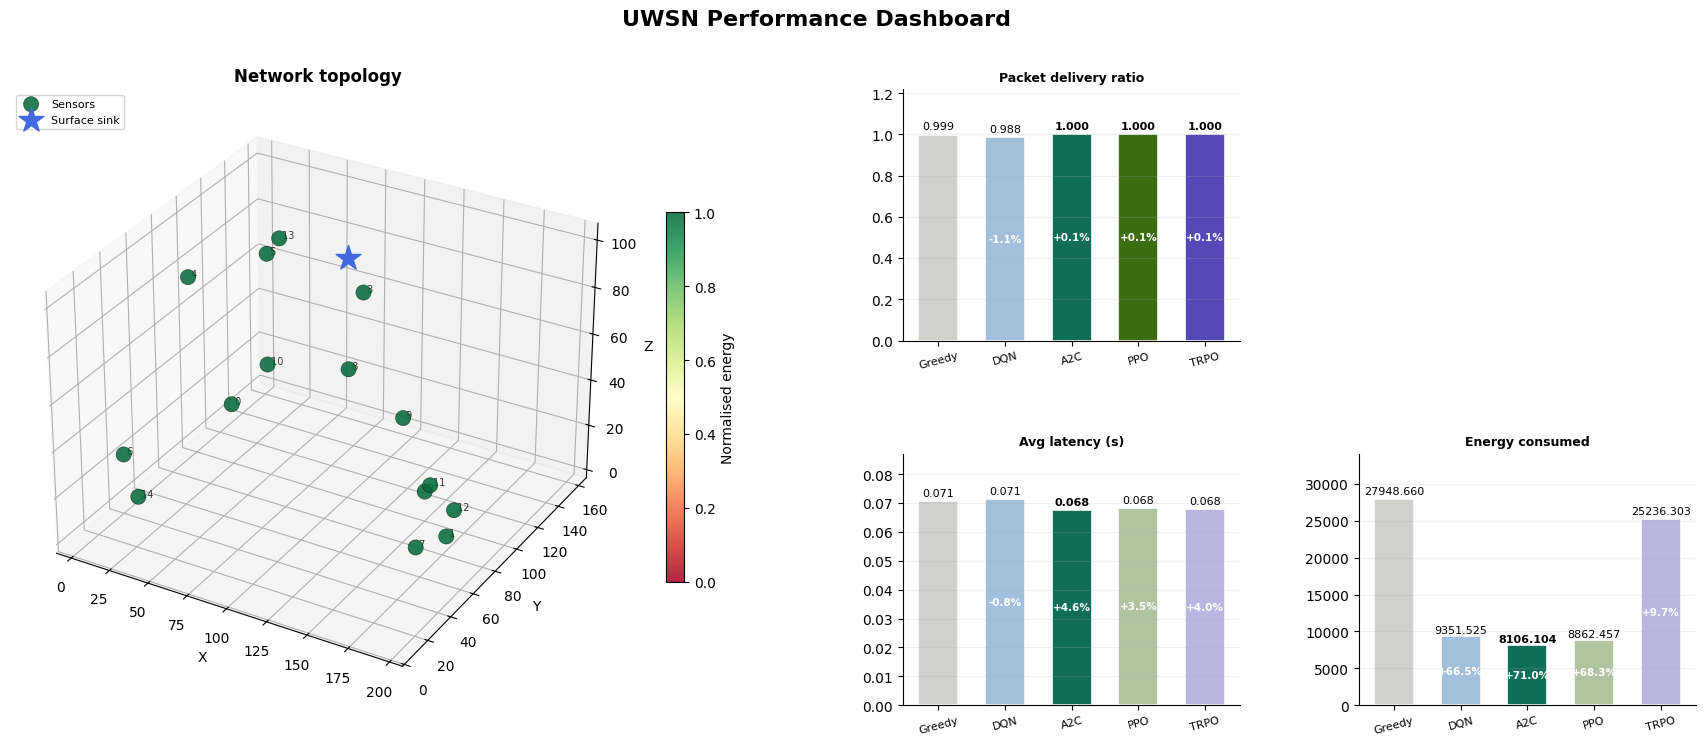

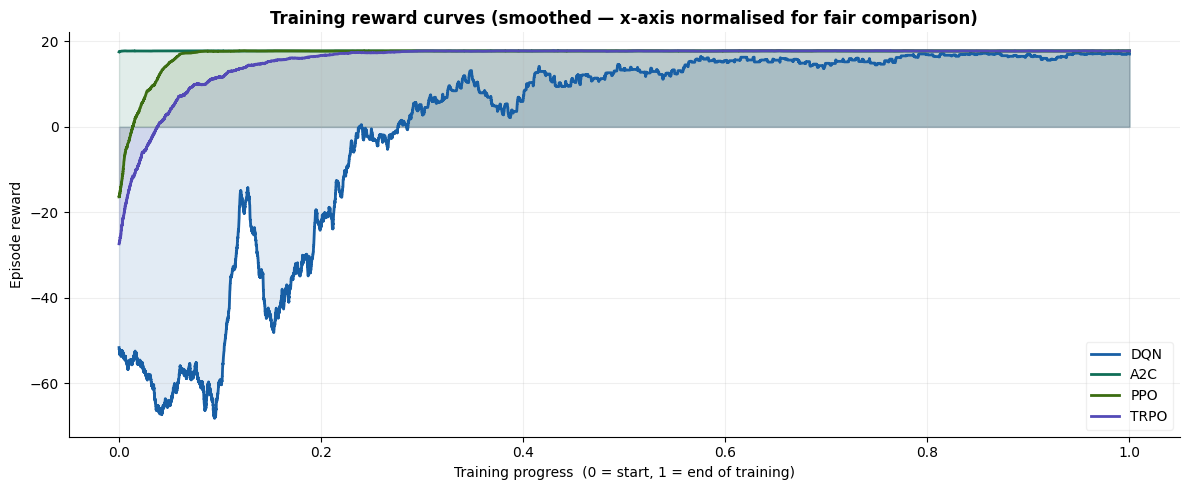

Visualization start node: 10, dist to surface: 142.0


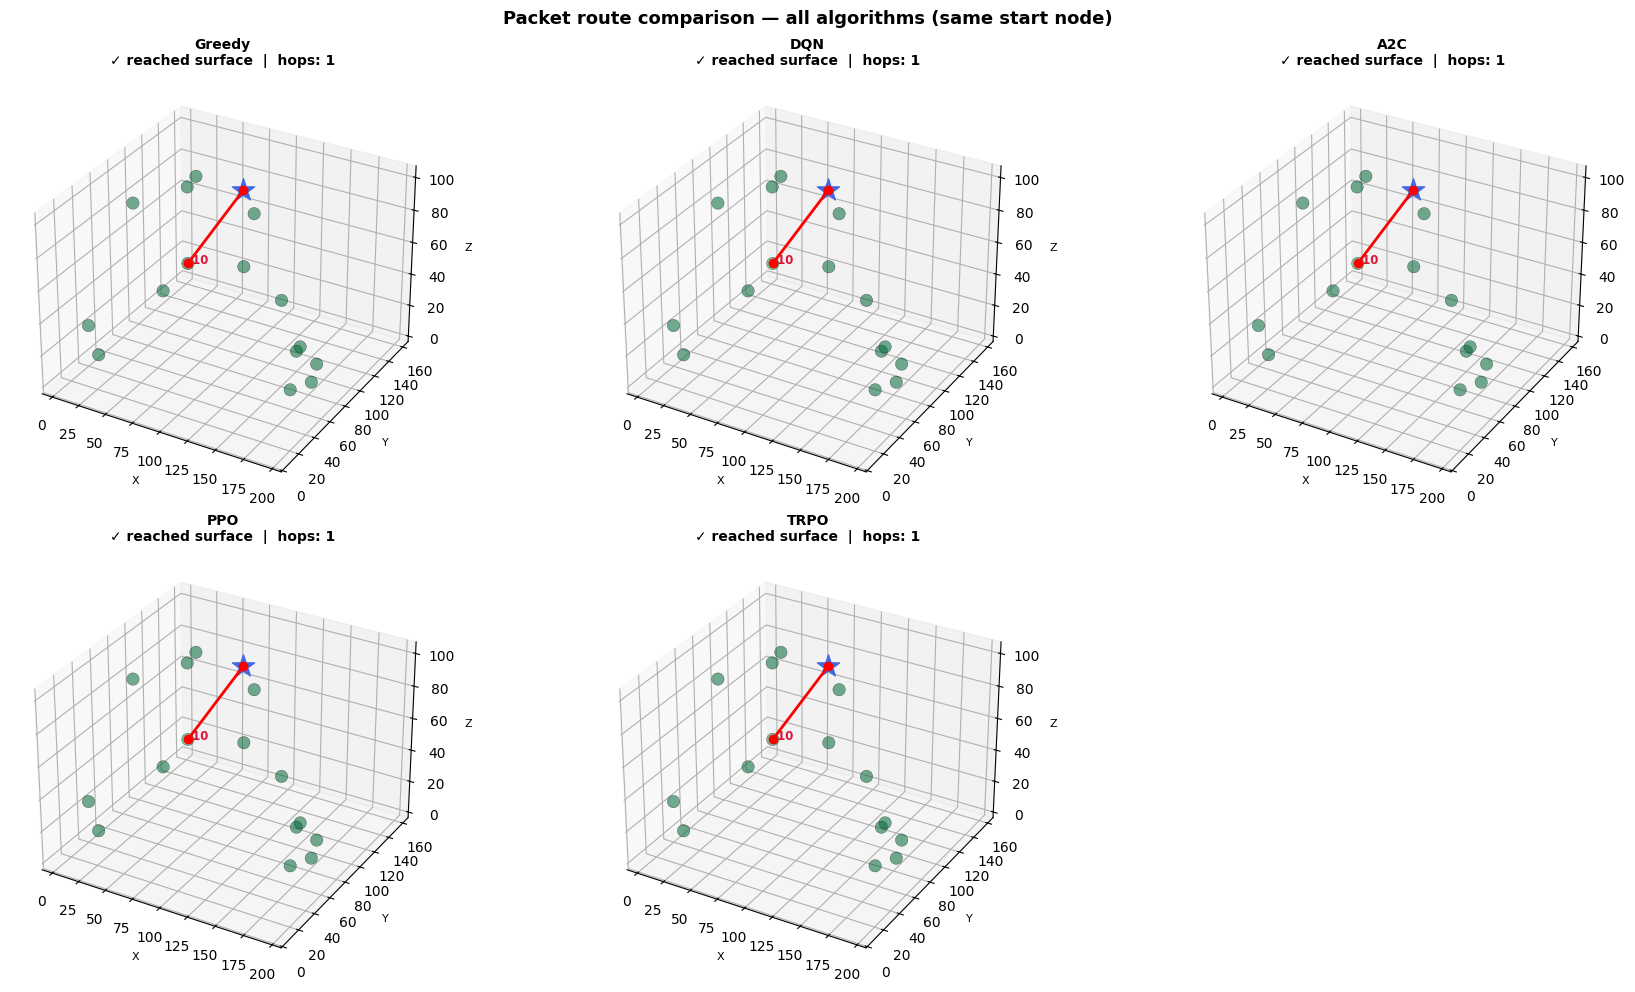

In [18]:
# ─────────────────────────────────────────────────
# 1. Dashboard: Network Topology & Algorithm Results
# ─────────────────────────────────────────────────
env_viz = UWSNEnvironmentFixed()
plot_topology_and_results(env_viz, results)

# ─────────────────────────────────────────────────
# 2. Training Reward Curves
# ─────────────────────────────────────────────────
plot_training_curves(reward_histories)

# ─────────────────────────────────────────────────
# 3. Packet Route Comparison — All Algorithms
# ─────────────────────────────────────────────────
env_route = UWSNEnvironmentFixed()
plot_route_comparison(env_route)
